# Análisis de Errores
¿Qué churners no detectamos (FN)? ¿Qué renewals se alarman en falso (FP)?
Ayuda a entender los límites del modelo y guiar mejoras.

In [1]:
import sys
from pathlib import Path
ROOT = Path('..').resolve()
sys.path.append(str(ROOT))

from src.models.error_analysis_08 import (
    load_labeled_test, classify_predictions, analyze_errors,
    plot_confusion_heatmap, plot_error_distributions, plot_score_by_result,
)
from src.models.train_06 import best_f1_threshold, MODELS_DIR, FEATURE_COLS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Cargar datos y modelo

In [2]:
df_test, X_test, y_test = load_labeled_test()
artifact = joblib.load(MODELS_DIR / 'best_model.joblib')
model = artifact['model']
print(f'Modelo: {artifact["name"]} | test: {len(df_test):,} usuarios')

proba = model.predict_proba(X_test)[:, 1]
threshold = best_f1_threshold(y_test, proba)
preds = (proba >= threshold).astype(int)
print(f'Umbral óptimo F1: {threshold:.3f}')

Modelo: LightGBM | test: 198,587 usuarios
Umbral óptimo F1: 0.891


## 2. Matriz de confusión

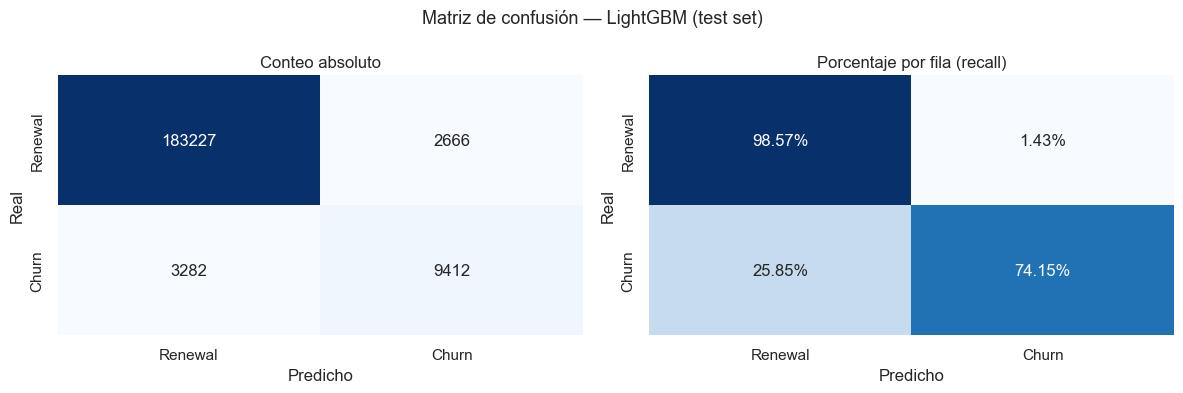

In [3]:
plot_confusion_heatmap(y_test, preds)

## 3. Clasificación de predicciones (TP / FP / FN / TN)

In [4]:
df_labeled = classify_predictions(df_test, proba, y_test, threshold)
analyze_errors(df_labeled)
df_labeled['result'].value_counts()

═══════════════════════════════════════════════════════
MATRIZ DE CONFUSIÓN
  TP (detectados)      :   9,412
  TN (correcto renewal): 183,227
  FP (falso alarma)    :   2,666
  FN (churners perdidos):   3,282

── Falsos negativos (FN=3,282) — churners que no detectamos ──
  proba_churn media : 0.675  (umbral=0.001)
  last_is_cancel    : 0.126  vs TP 0.472
  last_is_auto_renew: 0.214  vs TP 0.485
  days_since_last   : 5.0   vs TP 46.9
  n_transactions    : 12.2   vs TP 11.1

── Falsos positivos (FP=2,666) — renewals mal clasificados ──
  proba_churn media : 0.940
  last_is_cancel    : 0.458
  last_is_auto_renew: 0.466
  days_since_last   : 26.1


result
TN    183227
TP      9412
FN      3282
FP      2666
Name: count, dtype: int64

## 4. Distribuciones por tipo de error

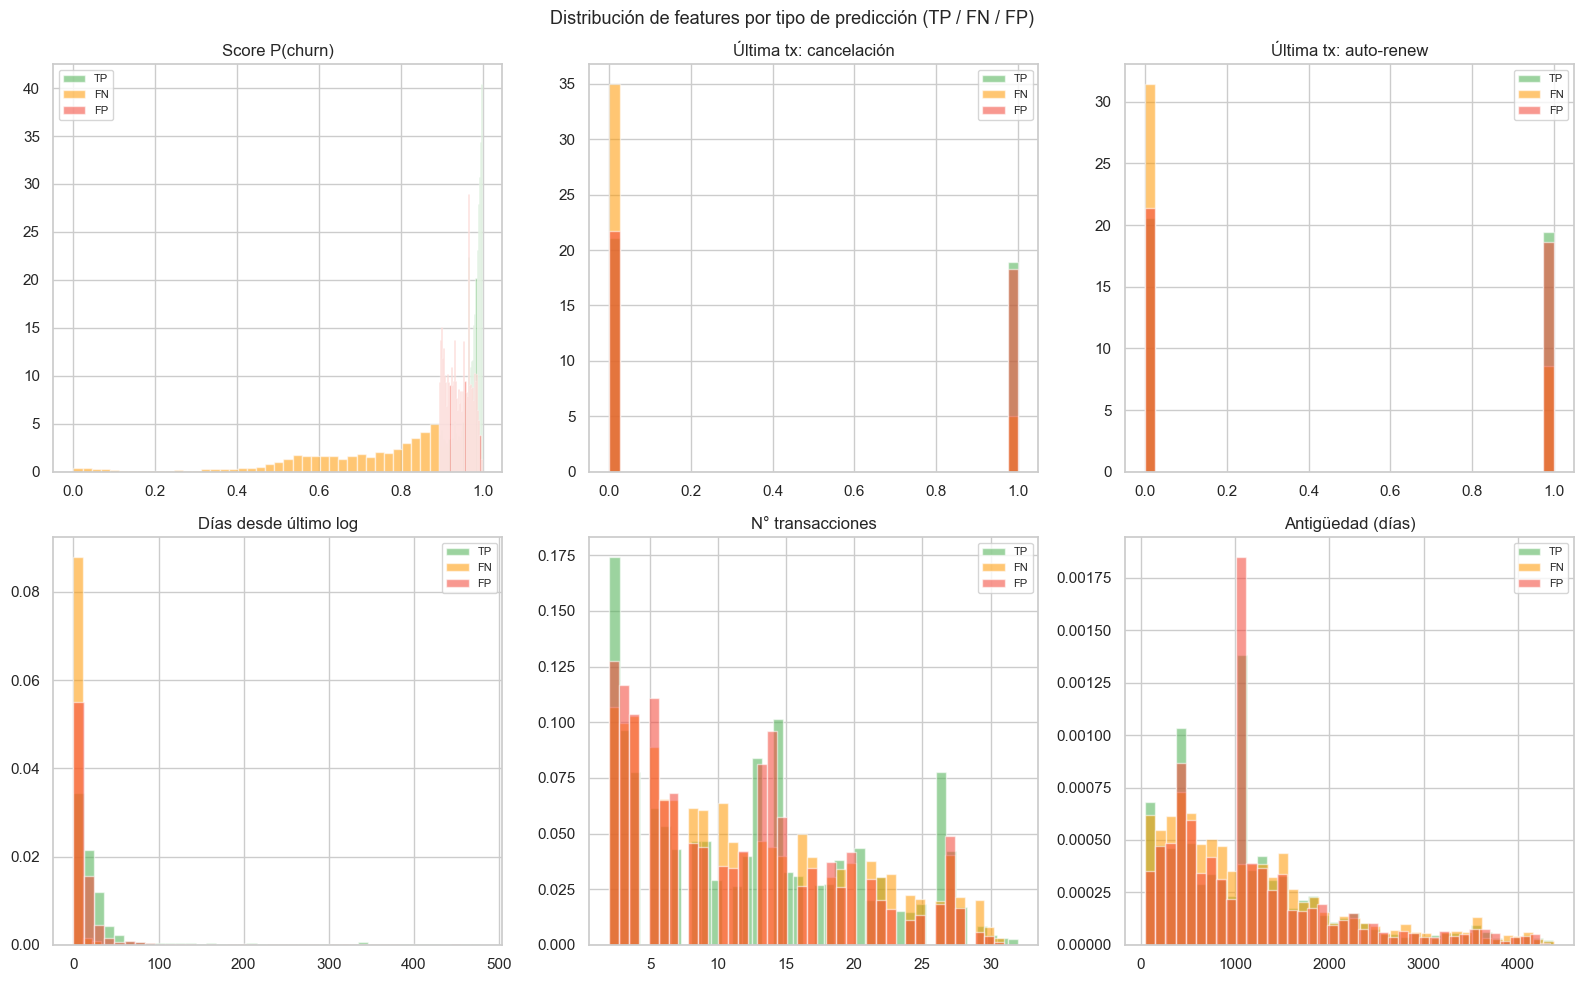

In [5]:
plot_error_distributions(df_labeled)

## 5. Scores de FN por características

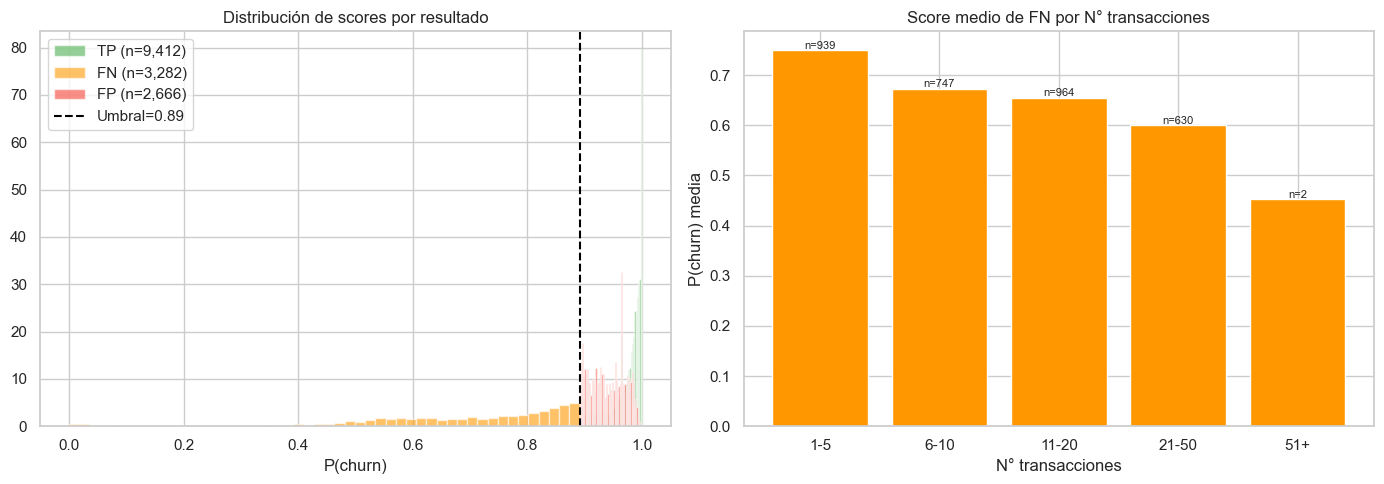

In [6]:
plot_score_by_result(df_labeled, threshold)

## 6. Perfil medio por resultado

In [7]:
profile_cols = [
    'last_is_cancel', 'last_is_auto_renew', 'n_transactions',
    'days_since_last', 'listening_trend', 'tenure_days',
    'ever_canceled', 'price_trend',
]
profile = df_labeled.groupby('result')[profile_cols].mean().T
profile.style.background_gradient(axis=1, cmap='RdYlGn')

result,FN,FP,TN,TP
last_is_cancel,0.125533,0.457989,0.015385,0.472163
last_is_auto_renew,0.213894,0.466242,0.924782,0.485019
n_transactions,12.193784,11.322206,17.607683,11.131428
days_since_last,5.011274,26.111778,21.963231,46.940395
listening_trend,-632.124379,-1629.152664,-748.329311,-2325.369281
tenure_days,1194.998781,1163.461740,1253.362670,1151.354335
ever_canceled,0.306825,0.522131,0.226517,0.542499
price_trend,75.816880,30.773068,-2.631708,29.973757
